# Find QSP and GQSP phases

**Download Notebook** - {nb-download}`qsp_angle_finder.ipynb`

Phase synthesis translates a target function into the classical parameters of a quantum signal-processing sequence. This notebook follows two routes: a Chebyshev approximation for QSP, and a Fourier approximation for generalized QSP (GQSP).

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from guppyalgos.utils import ChebyshevPolynomial, QSPAngleFinder
from guppyalgos.utils import FourierPolynomial, GQSPAngleFinder

## 1. QSP for an exponential filter

On $x\in[0,1]$, use the Gibbs-like filter $e^{-\beta x}$. QSP requires a definite parity, so extend it evenly:

$$
f(x)=e^{-\beta|x|},\qquad f(-x)=f(x).
$$

This is a filter function, rather than a normalized probability distribution. The helper below can construct even or odd extensions; this example uses the even one.

In [2]:
# Target functions 

def _gibbs_fun(x, beta):
    return np.exp(-beta * x)


def generate_gibbs_fun(beta):
    def fun(x):
        return _gibbs_fun(x, beta)

    return fun


def symmetrize_fun(fun, parity=0):
    if parity == 0:

        def neg_fun(x):
            return fun(-x)

        def pos_fun(x):
            return fun(x)

    if parity == 1:

        def neg_fun(x):
            return -fun(-x)

        def pos_fun(x):
            return fun(x)

    def sfun(x):
        if x < 0:
            return neg_fun(x)
        if x >= 0:
            return pos_fun(x)

    return np.vectorize(sfun)

In [3]:
beta = 2.5

gibbs_fun = generate_gibbs_fun(beta)
sym_gibbs_fun = symmetrize_fun(gibbs_fun, 0)
antisym_gibbs_fun = symmetrize_fun(gibbs_fun, 1)

### Approximate the function

`ChebyshevPolynomial` fits the even extension with a degree-16 polynomial:

$$
p_d(x)=\sum_{k=0}^{d}c_kT_k(x),\qquad d=16.
$$

The `.error` value reports the approximation error. Increasing the degree can improve the fit, at the cost of a longer quantum sequence.

In [4]:
d_phi = 16
d_cheb = d_phi

sym_gibbs_cheb = ChebyshevPolynomial(sym_gibbs_fun, d_cheb)
sym_gibbs_cheb.error

np.float64(0.08752003120788343)

### Optimize the phases

`QSPAngleFinder` chooses phase factors so that the QSP response approximates $p_d(x)$. Its `.opt_error` measures phase-synthesis error, separately from the polynomial approximation error. The plot compares the fitted polynomial with the synthesized response.

In [5]:
qsp_optimizer = QSPAngleFinder(d_phi=d_phi, target_polynomial=sym_gibbs_cheb)
qsp_optimizer.opt_error

np.float64(1.143961726692128e-09)

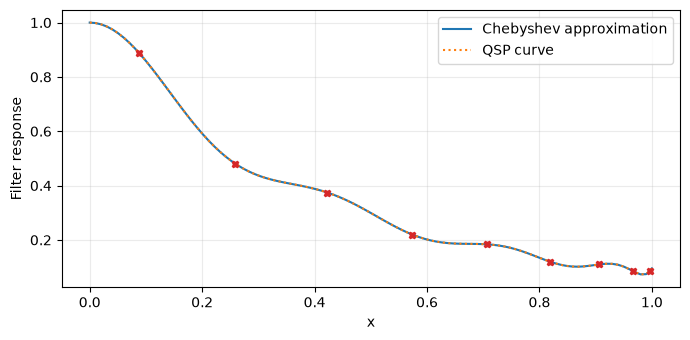

In [6]:
plt.figure(figsize=(7, 3.5))
x_vals=np.linspace(0, 1, 100)
f_vals = qsp_optimizer(x=x_vals)
plt.plot(x_vals, qsp_optimizer.target_polynomial(x_vals), label="Chebyshev approximation")
plt.plot(x_vals, f_vals, linestyle="dotted", label="QSP curve")
for x_j in qsp_optimizer.x_Chebyshev_roots:
    plt.plot(
        [x_j],
        [qsp_optimizer.target_polynomial(x_j)],
        color="C3",
        marker="X",
        markersize=5,
    )
plt.xlabel("x")
plt.ylabel("Filter response")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.legend()
plt.show()

## 2. GQSP from a Fourier series

GQSP represents a function of a unitary using a Laurent polynomial:

$$
F(z)=\sum_{k=-20}^{20}c_kz^k,\qquad z=e^{i\pi x}.
$$

For the periodic extension of $e^{-\tau\pi|x|}$ on $[-1,1]$, use

$$
c_k=\frac{\tau\bigl(1-(-1)^k e^{-\pi\tau}\bigr)}{\pi(\tau^2+k^2)}.
$$

`FourierPolynomial` stores these coefficients. The first plot shows the truncated series and its target.

In [7]:
tau = 1.2
degree = 40

d_max = degree // 2
d_min = - degree // 2

f_coeffs = {
    k : (tau*(1+((-1)**(k+1))*np.exp(-np.pi*tau)))/(np.pi*(tau**2 + k**2))
    for k in range(d_min, d_max+1)
}

f = FourierPolynomial(f_coeffs, d_max, d_min)

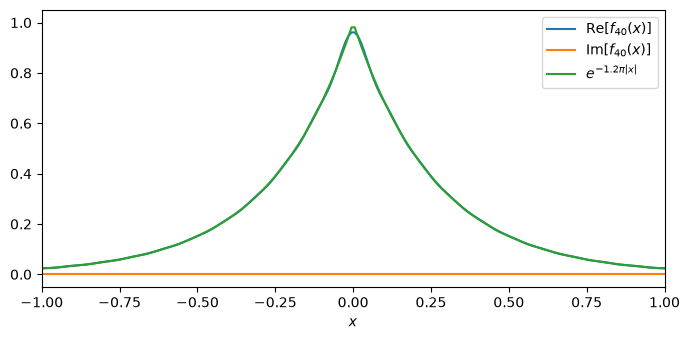

In [8]:
plt.figure(figsize=(7, 3.5))
xax = np.linspace(-1, 1, 200)
plt.plot(xax, f(xax).real, label=rf'Re$[f_{{{degree}}}(x)]$', color='C0')
plt.plot(xax, f(xax).imag, label=rf'Im$[f_{{{degree}}}(x)]$', color='C1')
plt.plot(xax, np.exp(-tau*np.pi*np.abs(xax)), label=rf'$e^{{-{float(tau):.3} \pi |x|}}$', color='C2')
plt.legend()
plt.xlim(-1, 1)
plt.ylim(-0.05,1.05)
plt.xlabel(r'$x$')
plt.tight_layout()

### Construct the complementary polynomial

`GQSPAngleFinder` constructs a second polynomial $Q$ so that, on the unit circle,

$$
|F(z)|^2+|Q(z)|^2=1.
$$

This is the normalization needed to embed the polynomial in a unitary. The construction requires a bounded target; finite-precision arithmetic can leave a small numerical residual.

In [9]:
angle_finder = GQSPAngleFinder(f)

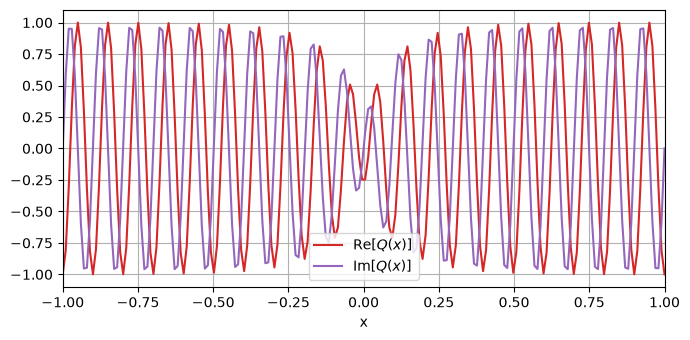

In [10]:
plt.figure(figsize=(7, 3.5))
# Let us plot the complementary function h(x)

q = angle_finder.complementary_polynomial
plt.plot(xax, q(xax).real, label=r'Re$[ Q(x) ]$', color='C3')
plt.plot(xax, q(xax).imag, label=r'Im$[ Q(x) ]$', color='C4')
plt.xlim(-1,1)
plt.xlabel(r'x')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
residual = np.max(np.abs(np.abs(f(xax))**2 + np.abs(q(xax))**2 - 1))
print(f"Maximum normalization residual on the grid: {residual:.2e}")

Maximum normalization residual on the grid: 1.63e-13


### Retrieve the phase factors

`.phase_factors` contains the parameters for the GQSP sequence. The preceding residual checks the complementary-polynomial condition; it is not a measure of the original Fourier approximation error.

In [12]:
phase_factors = angle_finder.phase_factors